# Лабораторная работа №6

**Студент:** Тавуз Мохамад  
**Группа:** ИУ5И-22М  

**Тема:** Предобработка и классификация текста.

In [1]:
# Подготовка среды выполнения: установка библиотек и загрузка языковой модели

!pip -q install spacy gensim nltk scikit-learn pandas numpy matplotlib
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 102.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Импорт необходимых библиотек и проверка загрузки модели spaCy

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spacy
import nltk
import gensim

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from gensim.models import Word2Vec

nlp = spacy.load("en_core_web_sm")

print("Библиотеки успешно импортированы.")
print("Модель spaCy успешно загружена:", nlp.meta["name"])

Библиотеки успешно импортированы.
Модель spaCy успешно загружена: core_web_sm


## Часть 1. Предобработка текста

В первой части лабораторной работы для произвольного текста выполняются основные этапы предобработки: токенизация, частеречная разметка, лемматизация, выделение именованных сущностей и синтаксический разбор предложения.

In [3]:
# Задание исходного текста для выполнения этапов предобработки

text = """
Apple announced a new artificial intelligence system in California in 2024.
The company plans to integrate this technology into its products for users around the world.
"""

doc = nlp(text)

print("Исходный текст:")
print(text)

print("\nКоличество символов:", len(text))
print("Количество токенов:", len(doc))
print("Количество предложений:", len(list(doc.sents)))

Исходный текст:

Apple announced a new artificial intelligence system in California in 2024.
The company plans to integrate this technology into its products for users around the world.


Количество символов: 170
Количество токенов: 31
Количество предложений: 2


In [4]:
# Выполнение токенизации исходного текста

tokens_data = []

for token in doc:
    tokens_data.append({
        "Токен": token.text,
        "Индекс": token.i,
        "Является пунктуацией": token.is_punct,
        "Является пробелом": token.is_space
    })

tokens_df = pd.DataFrame(tokens_data)

print("Результат токенизации текста:")
display(tokens_df)

Результат токенизации текста:


,Токен,Индекс,Является пунктуацией,Является пробелом
0,\n,0,False,True
1,Apple,1,False,False
2,announced,2,False,False
3,a,3,False,False
4,new,4,False,False
5,artificial,5,False,False
6,intelligence,6,False,False
7,system,7,False,False
8,in,8,False,False
9,California,9,False,False


In [5]:
# Выполнение частеречной разметки и лемматизации токенов

pos_lemma_data = []

for token in doc:
    if not token.is_space:
        pos_lemma_data.append({
            "Токен": token.text,
            "Лемма": token.lemma_,
            "Часть речи": token.pos_,
            "Подробный тег": token.tag_,
            "Описание тега": spacy.explain(token.tag_)
        })

pos_lemma_df = pd.DataFrame(pos_lemma_data)

print("Результат частеречной разметки и лемматизации:")
display(pos_lemma_df)

Результат частеречной разметки и лемматизации:


,Токен,Лемма,Часть речи,Подробный тег,Описание тега
0,Apple,Apple,PROPN,NNP,"noun, proper singular"
1,announced,announce,VERB,VBD,"verb, past tense"
2,a,a,DET,DT,determiner
3,new,new,ADJ,JJ,"adjective (English), other noun-modifier (Chin..."
4,artificial,artificial,ADJ,JJ,"adjective (English), other noun-modifier (Chin..."
5,intelligence,intelligence,NOUN,NN,"noun, singular or mass"
6,system,system,NOUN,NN,"noun, singular or mass"
7,in,in,ADP,IN,"conjunction, subordinating or preposition"
8,California,California,PROPN,NNP,"noun, proper singular"
9,in,in,ADP,IN,"conjunction, subordinating or preposition"


In [6]:
# Выделение именованных сущностей в исходном тексте

entities_data = []

for ent in doc.ents:
    entities_data.append({
        "Сущность": ent.text,
        "Тип": ent.label_,
        "Описание типа": spacy.explain(ent.label_),
        "Начальная позиция": ent.start_char,
        "Конечная позиция": ent.end_char
    })

entities_df = pd.DataFrame(entities_data)

print("Распознанные именованные сущности:")
display(entities_df)

Распознанные именованные сущности:


,Сущность,Тип,Описание типа,Начальная позиция,Конечная позиция
0,Apple,ORG,"Companies, agencies, institutions, etc.",1,6
1,California,GPE,"Countries, cities, states",57,67
2,2024,DATE,Absolute or relative dates or periods,71,75


In [7]:
# Выполнение синтаксического разбора предложений исходного текста

parse_data = []

for token in doc:
    if not token.is_space:
        parse_data.append({
            "Токен": token.text,
            "Лемма": token.lemma_,
            "Часть речи": token.pos_,
            "Синтаксическая роль": token.dep_,
            "Описание роли": spacy.explain(token.dep_),
            "Главное слово": token.head.text
        })

parse_df = pd.DataFrame(parse_data)

print("Результат синтаксического разбора предложений:")
display(parse_df)

Результат синтаксического разбора предложений:


,Токен,Лемма,Часть речи,Синтаксическая роль,Описание роли,Главное слово
0,Apple,Apple,PROPN,nsubj,nominal subject,announced
1,announced,announce,VERB,ROOT,root,announced
2,a,a,DET,det,determiner,system
3,new,new,ADJ,amod,adjectival modifier,system
4,artificial,artificial,ADJ,amod,adjectival modifier,system
5,intelligence,intelligence,NOUN,compound,compound,system
6,system,system,NOUN,dobj,direct object,announced
7,in,in,ADP,prep,prepositional modifier,system
8,California,California,PROPN,pobj,object of preposition,in
9,in,in,ADP,prep,prepositional modifier,announced


## Часть 2. Классификация текстов

Во второй части лабораторной работы решается задача классификации текстов на основе набора данных 20 Newsgroups. Для сравнения используются два подхода: классификация на основе TF-IDF и классификация на основе векторных представлений Word2Vec.

In [8]:
# Загрузка набора данных 20 Newsgroups для задачи классификации текстов

categories = [
    "rec.sport.baseball",
    "sci.space",
    "comp.graphics",
    "talk.politics.misc"
]

dataset = fetch_20newsgroups(
    subset="all",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=42
)

texts = dataset.data
labels = dataset.target
target_names = dataset.target_names

print("Набор данных успешно загружен.")
print("Количество текстов:", len(texts))
print("Количество классов:", len(target_names))
print("Названия классов:", target_names)

class_distribution = pd.Series(labels).value_counts().sort_index()
class_distribution_df = pd.DataFrame({
    "Класс": target_names,
    "Количество документов": class_distribution.values
})

print("\nРаспределение документов по классам:")
display(class_distribution_df)

print("\nПример текста:")
print(texts[0][:1000])
print("\nКласс примера:", target_names[labels[0]])

Набор данных успешно загружен.
Количество текстов: 3729
Количество классов: 4
Названия классов: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']

Распределение документов по классам:


,Класс,Количество документов
0,comp.graphics,973
1,rec.sport.baseball,994
2,sci.space,987
3,talk.politics.misc,775



Пример текста:

Are you kidding?  I'm stuck with the Toronto SkyDome, where their idea
of a 7th inning stretch is that "Blue Jays" song where everyone gets
to yell:  "Okay, okay, Blue Jays, Blue Jays, Let's Play Ball!"

Wow.. what genius did it take to compose that one, to outshine the
old classic.  And there are women on the field to "lead the crowd".

Класс примера: rec.sport.baseball


In [9]:
# Разделение набора данных на обучающую и тестовую выборки

X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

print("Разделение данных выполнено.")
print("Размер обучающей выборки:", len(X_train))
print("Размер тестовой выборки:", len(X_test))

train_distribution = pd.Series(y_train).value_counts().sort_index()
test_distribution = pd.Series(y_test).value_counts().sort_index()

split_distribution_df = pd.DataFrame({
    "Класс": target_names,
    "Обучающая выборка": train_distribution.values,
    "Тестовая выборка": test_distribution.values
})

print("\nРаспределение документов после разделения:")
display(split_distribution_df)

Разделение данных выполнено.
Размер обучающей выборки: 2796
Размер тестовой выборки: 933

Распределение документов после разделения:


,Класс,Обучающая выборка,Тестовая выборка
0,comp.graphics,730,243
1,rec.sport.baseball,745,249
2,sci.space,740,247
3,talk.politics.misc,581,194


### Способ 1. Классификация текста на основе TF-IDF

В первом способе тексты преобразуются в числовые векторы с помощью TfidfVectorizer. После этого для классификации используется модель LogisticRegression.

In [10]:
# Обучение модели классификации на основе TF-IDF и LogisticRegression

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

tfidf_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

tfidf_model.fit(X_train_tfidf, y_train)
y_pred_tfidf = tfidf_model.predict(X_test_tfidf)

tfidf_accuracy = accuracy_score(y_test, y_pred_tfidf)

print("Модель TF-IDF + LogisticRegression обучена.")
print("Размер матрицы признаков обучающей выборки:", X_train_tfidf.shape)
print("Размер матрицы признаков тестовой выборки:", X_test_tfidf.shape)
print("Accuracy модели TF-IDF:", round(tfidf_accuracy, 4))

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_tfidf, target_names=target_names))

Модель TF-IDF + LogisticRegression обучена.
Размер матрицы признаков обучающей выборки: (2796, 10000)
Размер матрицы признаков тестовой выборки: (933, 10000)
Accuracy модели TF-IDF: 0.8928

Отчет о классификации:
                    precision    recall  f1-score   support

     comp.graphics       0.94      0.93      0.94       243
rec.sport.baseball       0.91      0.85      0.88       249
         sci.space       0.81      0.94      0.87       247
talk.politics.misc       0.94      0.84      0.89       194

          accuracy                           0.89       933
         macro avg       0.90      0.89      0.89       933
      weighted avg       0.90      0.89      0.89       933



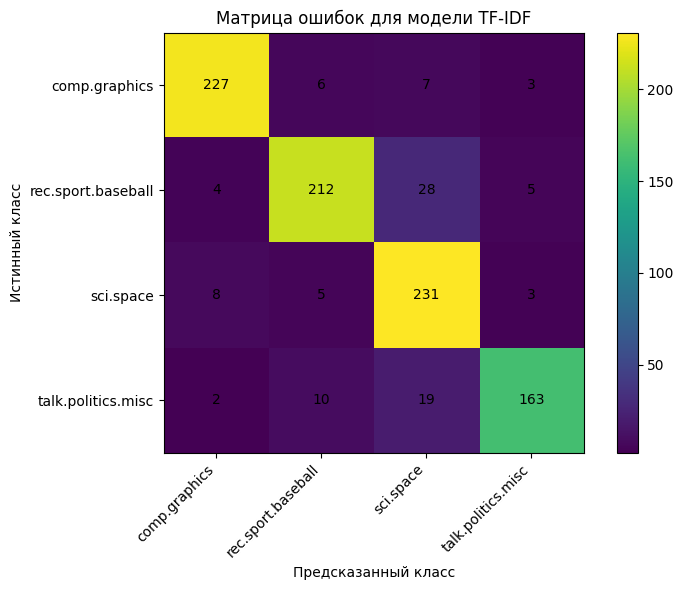

In [11]:
# Построение матрицы ошибок для модели на основе TF-IDF

tfidf_cm = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(8, 6))
plt.imshow(tfidf_cm)
plt.title("Матрица ошибок для модели TF-IDF")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(ticks=np.arange(len(target_names)), labels=target_names, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(target_names)), labels=target_names)

for i in range(tfidf_cm.shape[0]):
    for j in range(tfidf_cm.shape[1]):
        plt.text(j, i, tfidf_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

### Способ 2. Классификация текста на основе Word2Vec

Во втором способе для представления текстов используется модель Word2Vec. Сначала выполняется предварительная обработка текстов и обучение модели Word2Vec на обучающей выборке, затем каждый документ преобразуется в вектор путем усреднения векторов входящих в него слов.

In [12]:
# Предварительная обработка текстов для обучения модели Word2Vec

def preprocess_for_word2vec(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [token for token in tokens if len(token) > 2]
    return tokens

X_train_tokens = [preprocess_for_word2vec(text) for text in X_train]
X_test_tokens = [preprocess_for_word2vec(text) for text in X_test]

print("Предварительная обработка текстов для Word2Vec выполнена.")
print("Количество документов в обучающей выборке:", len(X_train_tokens))
print("Количество документов в тестовой выборке:", len(X_test_tokens))

print("\nПример исходного текста:")
print(X_train[0][:500])

print("\nПример токенизированного текста:")
print(X_train_tokens[0][:50])

Предварительная обработка текстов для Word2Vec выполнена.
Количество документов в обучающей выборке: 2796
Количество документов в тестовой выборке: 933

Пример исходного текста:
I have a routine that changes the color (RGB) attributes on my
VGA adapter, but it doesn't work in the mode that I need.  
Specifically 68 hex.  An obscure mode, of course, but I need to
change the zillions of colors to 64 shade greyscale, but I do
not have the correct memory address for the pointer I need.

PLEASE, someone, I need the starting address, or maybe somewhere 
I can find it.  Thank you.

Пример токенизированного текста:
['have', 'routine', 'that', 'changes', 'the', 'color', 'rgb', 'attributes', 'vga', 'adapter', 'but', 'doesn', 'work', 'the', 'mode', 'that', 'need', 'specifically', 'hex', 'obscure', 'mode', 'course', 'but', 'need', 'change', 'the', 'zillions', 'colors', 'shade', 'greyscale', 'but', 'not', 'have', 'the', 'correct', 'memory', 'address', 'for', 'the', 'pointer', 'need', 'please', 'som

In [13]:
# Обучение модели Word2Vec и преобразование документов в векторные представления

word2vec_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20,
    seed=42
)

def document_vector(tokens, model):
    vectors = []

    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_train_w2v = np.array([document_vector(tokens, word2vec_model) for tokens in X_train_tokens])
X_test_w2v = np.array([document_vector(tokens, word2vec_model) for tokens in X_test_tokens])

print("Модель Word2Vec обучена.")
print("Размер словаря Word2Vec:", len(word2vec_model.wv))
print("Размерность векторов слов:", word2vec_model.vector_size)
print("Размер матрицы признаков обучающей выборки:", X_train_w2v.shape)
print("Размер матрицы признаков тестовой выборки:", X_test_w2v.shape)

print("\nНаиболее похожие слова для слова space:")
print(word2vec_model.wv.most_similar("space", topn=10))

Модель Word2Vec обучена.
Размер словаря Word2Vec: 15597
Размерность векторов слов: 100
Размер матрицы признаков обучающей выборки: (2796, 100)
Размер матрицы признаков тестовой выборки: (933, 100)

Наиболее похожие слова для слова space:
[('sci', 0.5749902129173279), ('station', 0.5595186948776245), ('exploration', 0.5426974892616272), ('dawn', 0.5396639704704285), ('nasda', 0.5303415656089783), ('missions', 0.522962749004364), ('activist', 0.5206905603408813), ('soyuzkarta', 0.5203762054443359), ('restore', 0.5127167105674744), ('shuttle', 0.5109893083572388)]


In [14]:
# Обучение модели классификации на основе векторных представлений Word2Vec

word2vec_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

word2vec_classifier.fit(X_train_w2v, y_train)
y_pred_w2v = word2vec_classifier.predict(X_test_w2v)

word2vec_accuracy = accuracy_score(y_test, y_pred_w2v)

print("Модель Word2Vec + LogisticRegression обучена.")
print("Accuracy модели Word2Vec:", round(word2vec_accuracy, 4))

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_w2v, target_names=target_names))

Модель Word2Vec + LogisticRegression обучена.
Accuracy модели Word2Vec: 0.8907

Отчет о классификации:
                    precision    recall  f1-score   support

     comp.graphics       0.93      0.91      0.92       243
rec.sport.baseball       0.86      0.96      0.91       249
         sci.space       0.89      0.82      0.85       247
talk.politics.misc       0.90      0.87      0.88       194

          accuracy                           0.89       933
         macro avg       0.89      0.89      0.89       933
      weighted avg       0.89      0.89      0.89       933



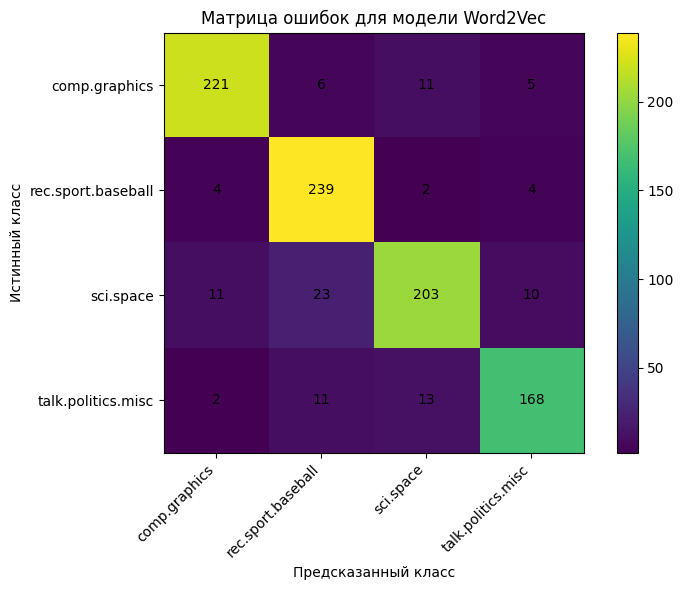

In [15]:
# Построение матрицы ошибок для модели на основе Word2Vec

word2vec_cm = confusion_matrix(y_test, y_pred_w2v)

plt.figure(figsize=(8, 6))
plt.imshow(word2vec_cm)
plt.title("Матрица ошибок для модели Word2Vec")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(ticks=np.arange(len(target_names)), labels=target_names, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(target_names)), labels=target_names)

for i in range(word2vec_cm.shape[0]):
    for j in range(word2vec_cm.shape[1]):
        plt.text(j, i, word2vec_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [16]:
# Сравнение качества моделей TF-IDF и Word2Vec

from sklearn.metrics import precision_recall_fscore_support

tfidf_precision, tfidf_recall, tfidf_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_tfidf,
    average="weighted"
)

word2vec_precision, word2vec_recall, word2vec_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_w2v,
    average="weighted"
)

comparison_df = pd.DataFrame({
    "Модель": [
        "TF-IDF + LogisticRegression",
        "Word2Vec + LogisticRegression"
    ],
    "Accuracy": [
        tfidf_accuracy,
        word2vec_accuracy
    ],
    "Precision": [
        tfidf_precision,
        word2vec_precision
    ],
    "Recall": [
        tfidf_recall,
        word2vec_recall
    ],
    "F1-score": [
        tfidf_f1,
        word2vec_f1
    ]
})

comparison_df[["Accuracy", "Precision", "Recall", "F1-score"]] = comparison_df[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].round(4)

print("Сравнение качества моделей:")
display(comparison_df)

best_model = comparison_df.loc[comparison_df["Accuracy"].idxmax(), "Модель"]
print("\nЛучшая модель по Accuracy:", best_model)

Сравнение качества моделей:


,Модель,Accuracy,Precision,Recall,F1-score
0,TF-IDF + LogisticRegression,0.8928,0.8975,0.8928,0.8932
1,Word2Vec + LogisticRegression,0.8907,0.8919,0.8907,0.8901



Лучшая модель по Accuracy: TF-IDF + LogisticRegression


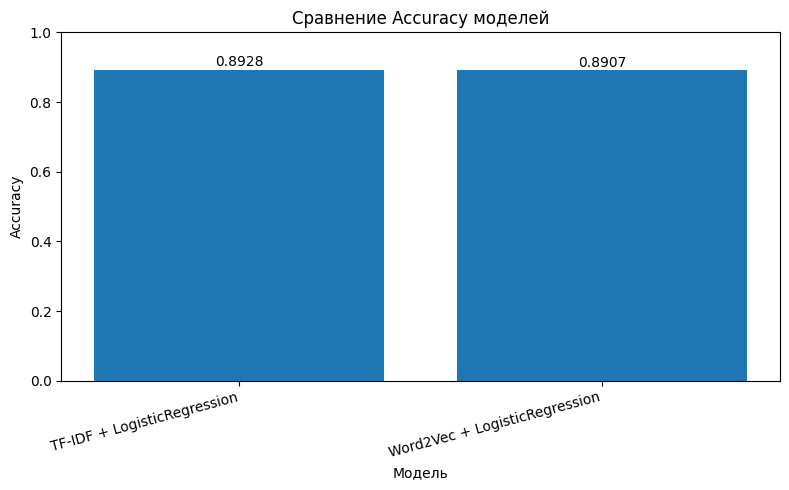

In [17]:
# Построение диаграммы сравнения Accuracy моделей TF-IDF и Word2Vec

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Модель"], comparison_df["Accuracy"])

plt.title("Сравнение Accuracy моделей")
plt.xlabel("Модель")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(comparison_df["Accuracy"]):
    plt.text(i, value + 0.01, str(value), ha="center")

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [18]:
# Формирование итоговой таблицы результатов лабораторной работы

final_results_df = pd.DataFrame({
    "Показатель": [
        "Набор данных",
        "Количество классов",
        "Количество документов",
        "Размер обучающей выборки",
        "Размер тестовой выборки",
        "Метод 1",
        "Accuracy метода 1",
        "Метод 2",
        "Accuracy метода 2",
        "Лучшая модель"
    ],
    "Значение": [
        "20 Newsgroups",
        len(target_names),
        len(texts),
        len(X_train),
        len(X_test),
        "TF-IDF + LogisticRegression",
        round(tfidf_accuracy, 4),
        "Word2Vec + LogisticRegression",
        round(word2vec_accuracy, 4),
        best_model
    ]
})

print("Итоговая таблица результатов лабораторной работы:")
display(final_results_df)

Итоговая таблица результатов лабораторной работы:


,Показатель,Значение
0,Набор данных,20 Newsgroups
1,Количество классов,4
2,Количество документов,3729
3,Размер обучающей выборки,2796
4,Размер тестовой выборки,933
5,Метод 1,TF-IDF + LogisticRegression
6,Accuracy метода 1,0.8928
7,Метод 2,Word2Vec + LogisticRegression
8,Accuracy метода 2,0.8907
9,Лучшая модель,TF-IDF + LogisticRegression
